<a href="https://colab.research.google.com/github/BALJITrs7/GNN-IDS/blob/main/gnn_iot2023_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import torch
import os

print("--- Preparing Enterprise Colab Environment ---")



# 2. Install PyTorch Geometric
print("Installing torch_geometric...")
!pip install -q torch_geometric

# 3. Fetch pre-compiled C++ cluster libraries based on your Colab PyTorch version
pt_version = torch.__version__
print(f"Detected PyTorch version: {pt_version}")
print("Installing torch-cluster...")
!pip install -q torch-cluster -f https://data.pyg.org/whl/torch-{pt_version}.html

print("\n--- Environment Ready! ---")

--- Preparing Enterprise Colab Environment ---
Installing torch_geometric...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 73.8 MB/s eta 0:00:00
Detected PyTorch version: 2.11.0+cu128
Installing torch-cluster...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 88.1 MB/s eta 0:00:00

--- Environment Ready! ---


In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
from google.colab import drive
import torch
import numpy as np
from sklearn.model_selection import train_test_split

print("--- 2. Restoring Graph Topology from Drive ---")
drive.mount('/content/drive')

# Load the 300k graph (weights_only=False bypasses PyTorch 2.6 security)
graph_data = torch.load('/content/drive/MyDrive/GNN_IDS_Project/cic_iot_300k_graph.pt', weights_only=False)
print(f"Graph loaded! Nodes: {graph_data.num_nodes} | Edges: {graph_data.num_edges}")

# Regenerate the exact 70/15/15 mathematical masks
print("Re-applying Stratified Data Split...")
indices = np.arange(graph_data.num_nodes)
labels = graph_data.y.numpy()

train_idx, temp_idx, _, temp_labels = train_test_split(indices, labels, test_size=0.3, stratify=labels, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=temp_labels, random_state=42)

graph_data.train_mask = torch.zeros(graph_data.num_nodes, dtype=torch.bool)
graph_data.val_mask = torch.zeros(graph_data.num_nodes, dtype=torch.bool)
graph_data.test_mask = torch.zeros(graph_data.num_nodes, dtype=torch.bool)

graph_data.train_mask[train_idx] = True
graph_data.val_mask[val_idx] = True
graph_data.test_mask[test_idx] = True

print("✅ Masks successfully applied!")

--- 2. Restoring Graph Topology from Drive ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Graph loaded! Nodes: 300000 | Edges: 1500175
Re-applying Stratified Data Split...
✅ Masks successfully applied!


In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv
from sklearn.metrics import precision_score, recall_score, f1_score
import gc

print("--- Initializing V2 Optimized GNN Engine ---")

# ==========================================
# 0. HARDWARE ACCELERATION (THE FIX)
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Hardware Engine Engaged: {device.type.upper()}")

# Move the massive 300k graph into the GPU VRAM
graph_data = graph_data.to(device)

# ==========================================
# 1. OPTIMIZED MODEL DEFINITIONS
# ==========================================
class GCN_V2(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.conv2(h, edge_index).relu()
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.classifier(h)

class GAT_V2(nn.Module):
    def __init__(self, hidden_channels, heads, in_dim, out_dim, dropout=0.5):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GATConv(in_dim, hidden_channels, heads)
        self.conv2 = GATConv(heads*hidden_channels, hidden_channels, heads)
        self.classifier = nn.Linear(heads*hidden_channels, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index).relu()
        h = F.dropout(h, p=self.dropout, training=self.training)
        h = self.conv2(h, edge_index).relu()
        h = F.dropout(h, p=self.dropout, training=self.training)
        return self.classifier(h)

# ==========================================
# 2. HYPERPARAMETER UPGRADES
# ==========================================
in_dim = 46
hidden_dim = 64
out_dim = len(torch.unique(graph_data.y))
heads = 4
epochs = 300     # Fixed back to 300 for V2
learning_rate = 0.005

models_to_test = {
    "GCN Optimized": GCN_V2(in_dim, hidden_dim, out_dim).to(device), # Moved to GPU
    "GAT Optimized": GAT_V2(hidden_dim, heads, in_dim, out_dim).to(device) # Moved to GPU
}

criterion = nn.CrossEntropyLoss()
results = {}

print(f"\n--- Starting {epochs}-Epoch Training ---")

for model_name, model in models_to_test.items():
    print(f"\nTraining {model_name}...")
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(graph_data.x, graph_data.edge_index)
        loss = criterion(out[graph_data.train_mask], graph_data.y[graph_data.train_mask])
        loss.backward()
        optimizer.step()

        # Telemetry: Print status every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:03d} | Loss: {loss.item():.4f}")

    # Evaluation Phase
    model.eval()
    with torch.no_grad():
        logits = model(graph_data.x, graph_data.edge_index)
        test_preds = torch.argmax(logits[graph_data.test_mask], dim=1)

        # Pull back to CPU for Scikit-Learn metrics
        y_true_test = graph_data.y[graph_data.test_mask].cpu().numpy()
        y_pred_test = test_preds.cpu().numpy()

        results[model_name] = {
            "Precision": precision_score(y_true_test, y_pred_test, average='macro', zero_division=0),
            "Recall": recall_score(y_true_test, y_pred_test, average='macro', zero_division=0),
            "F1-Score": f1_score(y_true_test, y_pred_test, average='macro', zero_division=0)
        }

    # Aggressive RAM Cleanup before the next model loads
    del optimizer, out, loss, logits, test_preds
    torch.cuda.empty_cache()
    gc.collect()

# ==========================================
# 3. FINAL V2 SCORECARD
# ==========================================
print("\n" + "="*55)
print(f"{'Model':<15} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 55)
for model_name, metrics in results.items():
    print(f"{model_name:<15} | {metrics['Precision']:.4f}     | {metrics['Recall']:.4f}     | {metrics['F1-Score']:.4f}")
print("="*55)

--- Initializing V2 Optimized GNN Engine ---
Hardware Engine Engaged: CUDA

--- Starting 300-Epoch Training ---

Training GCN Optimized...
Epoch 001 | Loss: 1.7981
Epoch 010 | Loss: 1.4951
Epoch 020 | Loss: 1.0560
Epoch 030 | Loss: 0.8466
Epoch 040 | Loss: 0.7531
Epoch 050 | Loss: 0.7020
Epoch 060 | Loss: 0.6671
Epoch 070 | Loss: 0.6399
Epoch 080 | Loss: 0.6140
Epoch 090 | Loss: 0.5907
Epoch 100 | Loss: 0.5749
Epoch 110 | Loss: 0.5632
Epoch 120 | Loss: 0.5536
Epoch 130 | Loss: 0.5458
Epoch 140 | Loss: 0.5413
Epoch 150 | Loss: 0.5356
Epoch 160 | Loss: 0.5309
Epoch 170 | Loss: 0.5273
Epoch 180 | Loss: 0.5235
Epoch 190 | Loss: 0.5213
Epoch 200 | Loss: 0.5186
Epoch 210 | Loss: 0.5162
Epoch 220 | Loss: 0.5134
Epoch 230 | Loss: 0.5115
Epoch 240 | Loss: 0.5070
Epoch 250 | Loss: 0.5066
Epoch 260 | Loss: 0.5045
Epoch 270 | Loss: 0.5037
Epoch 280 | Loss: 0.5017
Epoch 290 | Loss: 0.4997
Epoch 300 | Loss: 0.4980

Training GAT Optimized...
Epoch 001 | Loss: 1.7955
Epoch 010 | Loss: 0.8800
Epoch 020

In [7]:
import torch
import os


# Using the exact same secure project folder
save_path = '/content/drive/MyDrive/GNN_IDS_Project'
os.makedirs(save_path, exist_ok=True)

# Map the internal model names to your exact requested filenames
custom_filenames = {
    "GCN Optimized": "GCN_300k_weights_v2.pt",
    "GAT Optimized": "GAT_300k_weights_v2.pt"
}

# Loop through your newly trained V2 models and save them
for model_name, model in models_to_test.items():
    if model_name in custom_filenames:
        file_name = custom_filenames[model_name]
        file_path = os.path.join(save_path, file_name)

        # Extract and save the learnable weights
        torch.save(model.state_dict(), file_path)
        print(f"✅ Saved {model_name} weights to: {file_name}")


✅ Saved GCN Optimized weights to: GCN_300k_weights_v2.pt
✅ Saved GAT Optimized weights to: GAT_300k_weights_v2.pt


--- Generating V2 Comparative Analytics ---
Calculating mathematical metrics for V2 models...

Table: Statistics on standard metrics (in percentage) of V2 GNN models
       Dataset         Model  Prec Recall F1-score   AUC  FPR
Dataset 1 (V2) GCN Optimized 79.52  77.20    76.93 96.58 4.56
Dataset 1 (V2) GAT Optimized 79.35  78.54    78.45 97.03 4.29



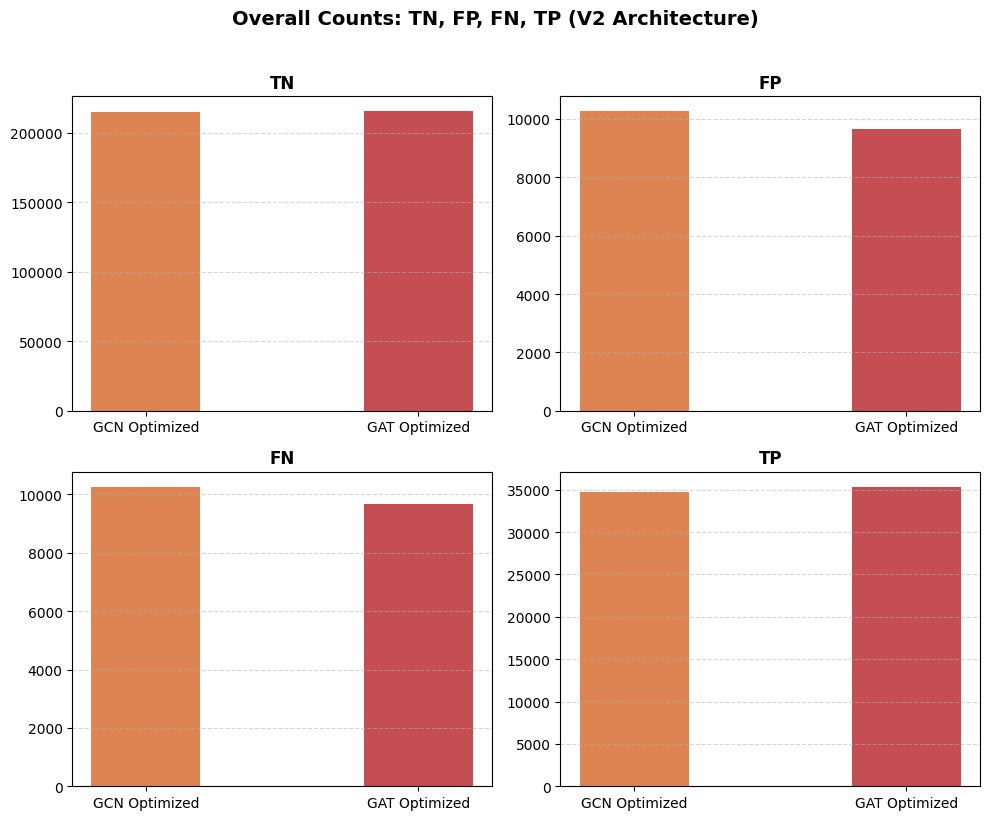


--- Deep Dive: V2 GAT Optimized ---

--- Test Results (V2 GAT) ---
              precision    recall  f1-score   support

      Benign     0.6736    0.7693    0.7183      7500
        DDoS     0.8502    0.6411    0.7310      7500
         DoS     0.7117    0.8825    0.7880      7500
       Mirai     0.9988    0.9931    0.9959      7500
       Recon     0.7510    0.7332    0.7420      7500
    Spoofing     0.7758    0.6931    0.7321      7500

    accuracy                         0.7854     45000
   macro avg     0.7935    0.7854    0.7845     45000
weighted avg     0.7935    0.7854    0.7845     45000



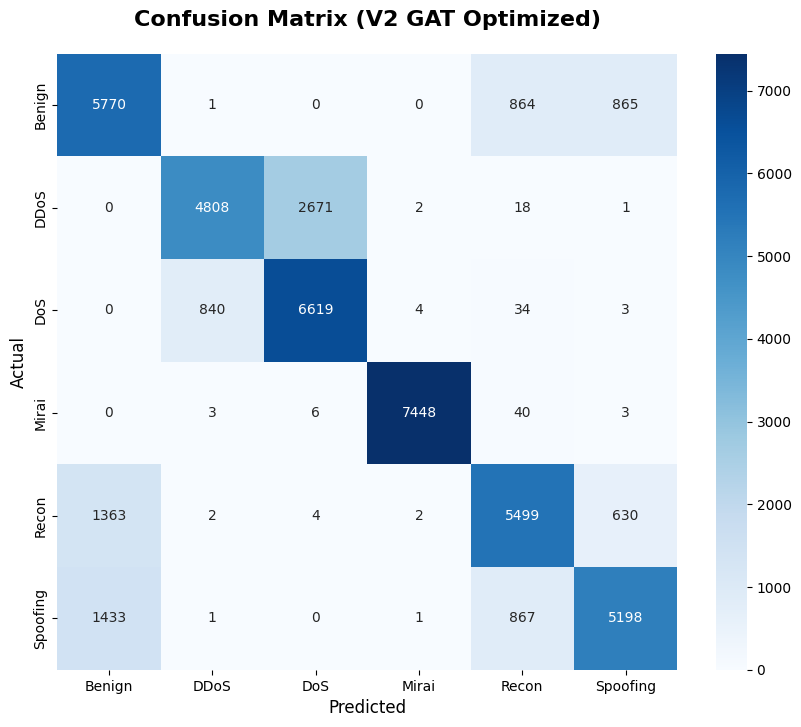

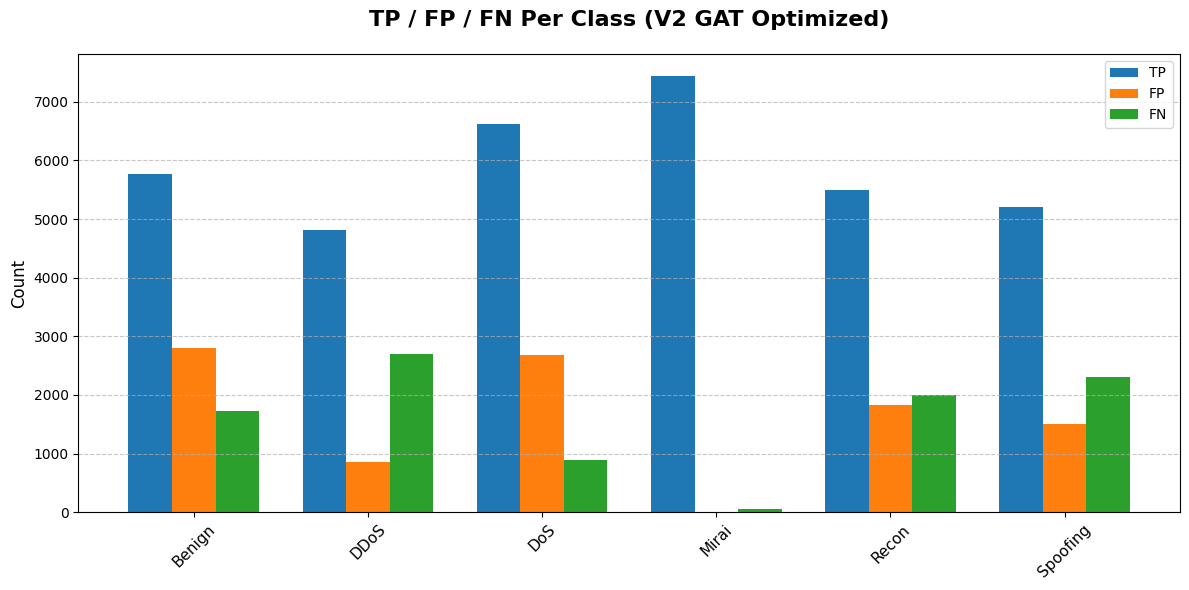

In [8]:
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("--- Generating V2 Comparative Analytics ---")

# Setup data structures
table_data = []
bar_data = {'TN': [], 'FP': [], 'FN': [], 'TP': []}
model_names = list(models_to_test.keys()) # Will pull "GCN Optimized" and "GAT Optimized"
class_names = ['Benign', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing']

# Extract ground truth labels for the test set
y_true = graph_data.y[graph_data.test_mask].cpu().numpy()

# 1. EVALUATE MODELS & EXTRACT METRICS

print("Calculating mathematical metrics for V2 models...")
with torch.no_grad():
    for name, model in models_to_test.items():
        model.eval()

        # Forward pass
        logits = model(graph_data.x, graph_data.edge_index)
        probs = F.softmax(logits[graph_data.test_mask], dim=1).cpu().numpy()
        preds = torch.argmax(logits[graph_data.test_mask], dim=1).cpu().numpy()

        # Core Metrics
        prec = precision_score(y_true, preds, average='macro', zero_division=0) * 100
        rec = recall_score(y_true, preds, average='macro', zero_division=0) * 100
        f1 = f1_score(y_true, preds, average='macro', zero_division=0) * 100
        auc = roc_auc_score(y_true, probs, multi_class='ovr', average='macro') * 100

        # Confusion Matrix Parsing
        cm = confusion_matrix(y_true, preds)
        FP = cm.sum(axis=0) - np.diag(cm)
        FN = cm.sum(axis=1) - np.diag(cm)
        TP = np.diag(cm)
        TN = cm.sum() - (FP + FN + TP)
        fpr = np.mean(FP / (FP + TN)) * 100 # Average FPR

        # Append to trackers
        table_data.append(["Dataset 1 (V2)", name, f"{prec:.2f}", f"{rec:.2f}", f"{f1:.2f}", f"{auc:.2f}", f"{fpr:.2f}"])
        bar_data['TN'].append(TN.sum())
        bar_data['FP'].append(FP.sum())
        bar_data['FN'].append(FN.sum())
        bar_data['TP'].append(TP.sum())


# OUTPUT 1: The Formatted Table

print("\n" + "="*85)
print("Table: Statistics on standard metrics (in percentage) of V2 GNN models")
print("="*85)
df = pd.DataFrame(table_data, columns=["Dataset", "Model", "Prec", "Recall", "F1-score", "AUC", "FPR"])
print(df.to_string(index=False))
print("="*85 + "\n")


# OUTPUT 2: The 2x2 Benchmark Plot (GCN vs GAT)

fig, axs = plt.subplots(2, 2, figsize=(10, 8))
colors = ['#dd8452', '#c44e52'] # Colors mapped to your 2 models
x_pos = np.arange(len(model_names))

def setup_ax(ax, title, data):
    ax.bar(x_pos, data, color=colors, width=0.4)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_names)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

setup_ax(axs[0, 0], 'TN', bar_data['TN'])
setup_ax(axs[0, 1], 'FP', bar_data['FP'])
setup_ax(axs[1, 0], 'FN', bar_data['FN'])
setup_ax(axs[1, 1], 'TP', bar_data['TP'])

plt.suptitle('Overall Counts: TN, FP, FN, TP (V2 Architecture)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


# OUTPUT 3: Deep Dive into GAT Optimized

print("\n--- Deep Dive: V2 GAT Optimized ---")

# Isolate predictions specifically for the GAT model
best_model = models_to_test["GAT Optimized"]
with torch.no_grad():
    logits = best_model(graph_data.x, graph_data.edge_index)
    preds_gat = torch.argmax(logits[graph_data.test_mask], dim=1).cpu().numpy()

# 3A. Classification Report
print("\n--- Test Results (V2 GAT) ---")
print(classification_report(y_true, preds_gat, target_names=class_names, digits=4))

# 3B. Confusion Matrix Heatmap
cm_gat = confusion_matrix(y_true, preds_gat)
plt.figure(figsize=(10, 8))
sns.heatmap(cm_gat, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (V2 GAT Optimized)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.show()


# OUTPUT 4: TP/FP/FN Per Class (V2 GAT)

FP_gat = cm_gat.sum(axis=0) - np.diag(cm_gat)
FN_gat = cm_gat.sum(axis=1) - np.diag(cm_gat)
TP_gat = np.diag(cm_gat)

x = np.arange(len(class_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, TP_gat, width, label='TP')
ax.bar(x, FP_gat, width, label='FP')
ax.bar(x + width, FN_gat, width, label='FN')

ax.set_ylabel('Count', fontsize=12)
ax.set_title('TP / FP / FN Per Class (V2 GAT Optimized)', fontsize=16, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=45, fontsize=11)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()